In [1]:
!python --version
!nvcc --version
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Python 3.12.13
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpnnh_u5pi".


In [2]:
import torch
print("Czy CUDA jest dostępna:", torch.cuda.is_available())
print("Liczba dostępnych GPU:", torch.cuda.device_count())
if torch.cuda.is_available():
  print("Nazwa GPU:", torch.cuda.get_device_name(0))

Czy CUDA jest dostępna: True
Liczba dostępnych GPU: 1
Nazwa GPU: Tesla T4


In [3]:
!nvidia-smi --query-gpu=name,compute_cap --format=csv

name, compute_cap
Tesla T4, 7.5


## Rozwiązanie

In [4]:
!nvcc add_vec_gpu_evtime.cu -o add_vec_gpu_evtime -arch=sm_75
!./add_vec_gpu_evtime > results.txt
!cat results.txt

(N = 1048576)
Block_Size, Avg_Elapsed_Time_ms
1, 2.471160
2, 1.227906
4, 0.615998
8, 0.321622
16, 0.178810
32, 0.100205
64, 0.060989
128, 0.062514
256, 0.059933
512, 0.061096
1024, 0.060910

(Block size = 256)
Vector_Length, Avg_Elapsed_Time_ms
1024, 0.011494
2048, 0.010992
4096, 0.011091
8192, 0.011218
16384, 0.011690
32768, 0.013069
65536, 0.013501
131072, 0.014766
262144, 0.017182
524288, 0.036075
1048576, 0.061347

(CPU)
Vector_Length, Avg_Elapsed_Time_ms
1024, 0.005251
2048, 0.008877
4096, 0.016934
8192, 0.031360
16384, 0.062672
32768, 0.123776
65536, 0.243058
131072, 0.500971
262144, 0.980662
524288, 2.038994
1048576, 5.434962

(Testing Block Size = 2048)
Attempting to launch kernel with 2048 threads per block...
CUDA Error Caught: invalid configuration argument
Error at index 0! Expected 8, got 0


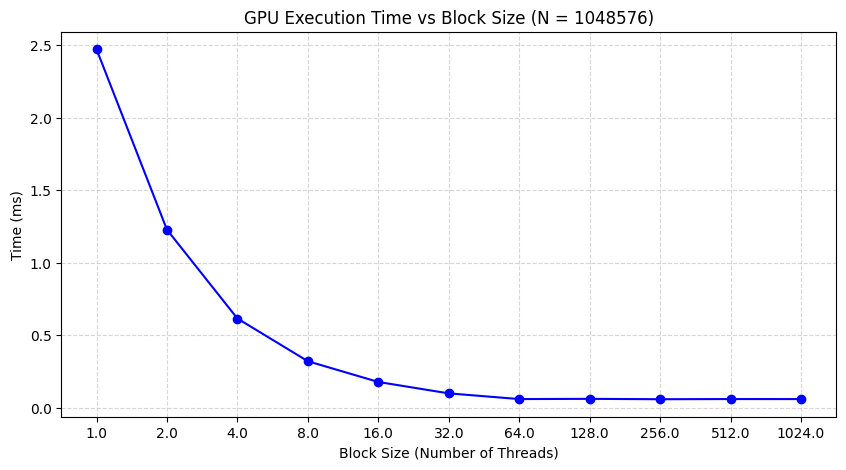

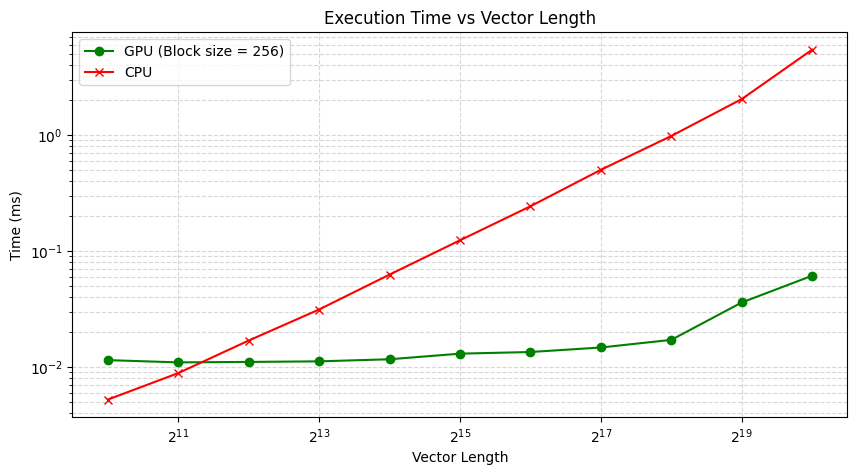

In [5]:
import matplotlib.pyplot as plt

# Initialize lists to hold our data
blocks = []
time_blocks = []

vec_gpu = []
time_gpu = []

vec_cpu = []
time_cpu = []

current_section = 0

# Parse the text file
with open('results.txt', 'r') as f:
    for line in f:
        line = line.strip()
        # Skip headers and empty lines
        if "Block_Size" in line or "Vector_Length" in line or line == "":
            continue

        # Detect sections
        if "(N =" in line:
            current_section = 1
            continue
        if "(Block size =" in line:
            current_section = 2
            continue
        if "(CPU)" in line:
            current_section = 3
            continue
        if "(Testing Block Size" in line:
            current_section = 4 # We don't want to plot the error test section
            continue

        # Parse comma-separated values
        parts = line.split(',')
        if len(parts) == 2:
            try:
                # Try to convert to floats. If it fails (because it's text), it goes to 'except'
                x = float(parts[0].strip())
                y = float(parts[1].strip())

                if current_section == 1:
                    blocks.append(x)
                    time_blocks.append(y)
                elif current_section == 2:
                    vec_gpu.append(x)
                    time_gpu.append(y)
                elif current_section == 3:
                    vec_cpu.append(x)
                    time_cpu.append(y)
            except ValueError:
                # Ignore lines that aren't pure numbers (like error messages with commas)
                continue

# ---------------------------------------------------------
# Plot 1: GPU Execution Time vs Block Size
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(blocks, time_blocks, marker='o', color='blue')
plt.xscale('log', base=2)
plt.title('GPU Execution Time vs Block Size (N = 1048576)')
plt.xlabel('Block Size (Number of Threads)')
plt.ylabel('Time (ms)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xticks(blocks, blocks)
plt.show()

# ---------------------------------------------------------
# Plot 2: Execution Time vs Vector Length (GPU vs CPU)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(vec_gpu, time_gpu, marker='o', color='green', label='GPU (Block size = 256)')
plt.plot(vec_cpu, time_cpu, marker='x', color='red', label='CPU')
plt.xscale('log', base=2)
plt.yscale('log')
plt.title('Execution Time vs Vector Length')
plt.xlabel('Vector Length')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Komentarz

Przy rozmiarze bloku 2048 kod skompiluje się lecz zwróci błędne wyniki. Możemy jednak sprawdzić status operacji za pomocą funkcji `cudaGetLastError()`.